In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# Basic overview
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Shape: (9994, 21)

Columns:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Data Types:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State            

In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
print("Date columns converted successfully")
print(df.head(2))

Date columns converted successfully
   Row ID        Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   

  Customer Name   Segment        Country       City  ...       Product ID  \
0   Claire Gute  Consumer  United States  Henderson  ...  FUR-BO-10001798   
1   Claire Gute  Consumer  United States  Henderson  ...  FUR-CH-10000454   

    Category Sub-Category                                       Product Name  \
0  Furniture    Bookcases                  Bush Somerset Collection Bookcase   
1  Furniture       Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs,...   

    Sales Quantity Discount    Profit  Year  Month  
0  261.96        2      0.0   41.9136  2016     11  
1  731.94        3      0.0  219.5820  2016     11  

[2 rows x 23 columns]


C:\Users\HP\AppData\Local\Temp\ipykernel_23588\2182305024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_r')


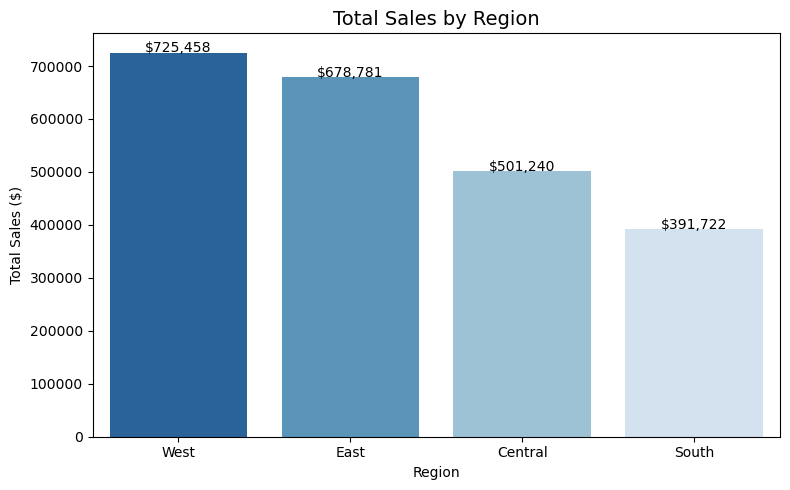

In [3]:
plt.figure(figsize=(8,5))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Blues_r')
plt.title('Total Sales by Region', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.xlabel('Region')
for i, v in enumerate(region_sales.values):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sales_by_region.png', dpi=150)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_23588\123139914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='Greens_r')


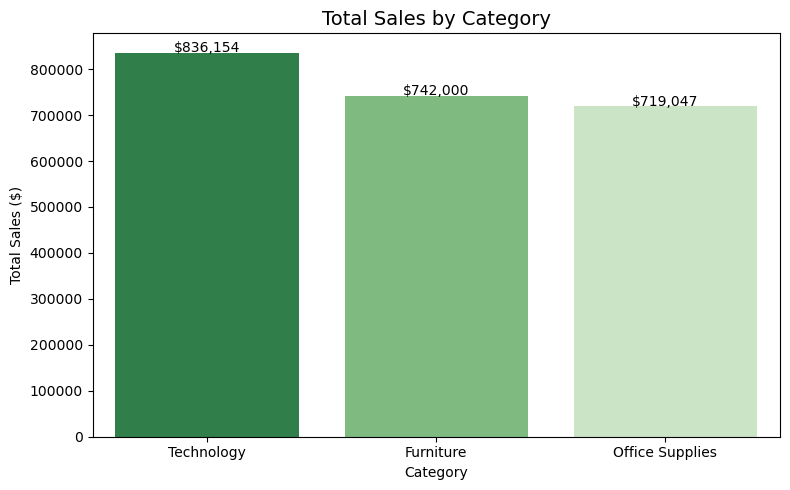

In [4]:
plt.figure(figsize=(8,5))
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='Greens_r')
plt.title('Total Sales by Category', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.xlabel('Category')
for i, v in enumerate(cat_sales.values):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('sales_by_category.png', dpi=150)
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_23588\3025122062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_profit.index, y=cat_profit.values, palette='Oranges_r')


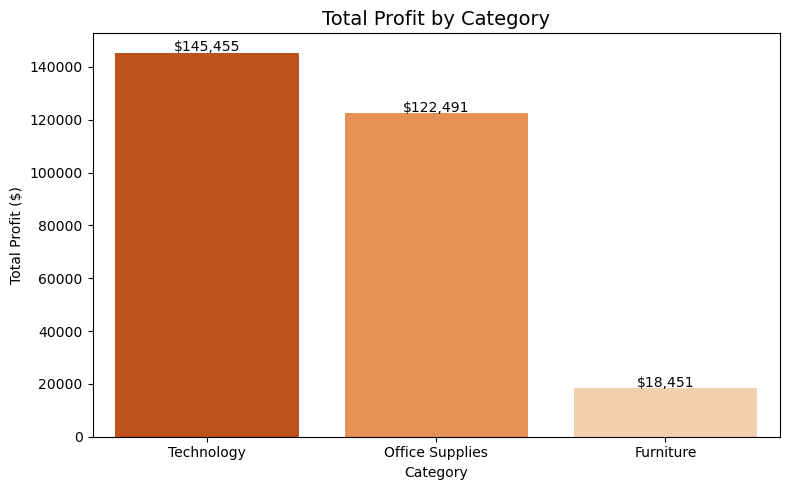

In [5]:
plt.figure(figsize=(8,5))
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=cat_profit.index, y=cat_profit.values, palette='Oranges_r')
plt.title('Total Profit by Category', fontsize=14)
plt.ylabel('Total Profit ($)')
plt.xlabel('Category')
for i, v in enumerate(cat_profit.values):
    plt.text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('profit_by_category.png', dpi=150)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_23588\1881740142.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat_margin.values, y=subcat_margin.index, palette=colors)


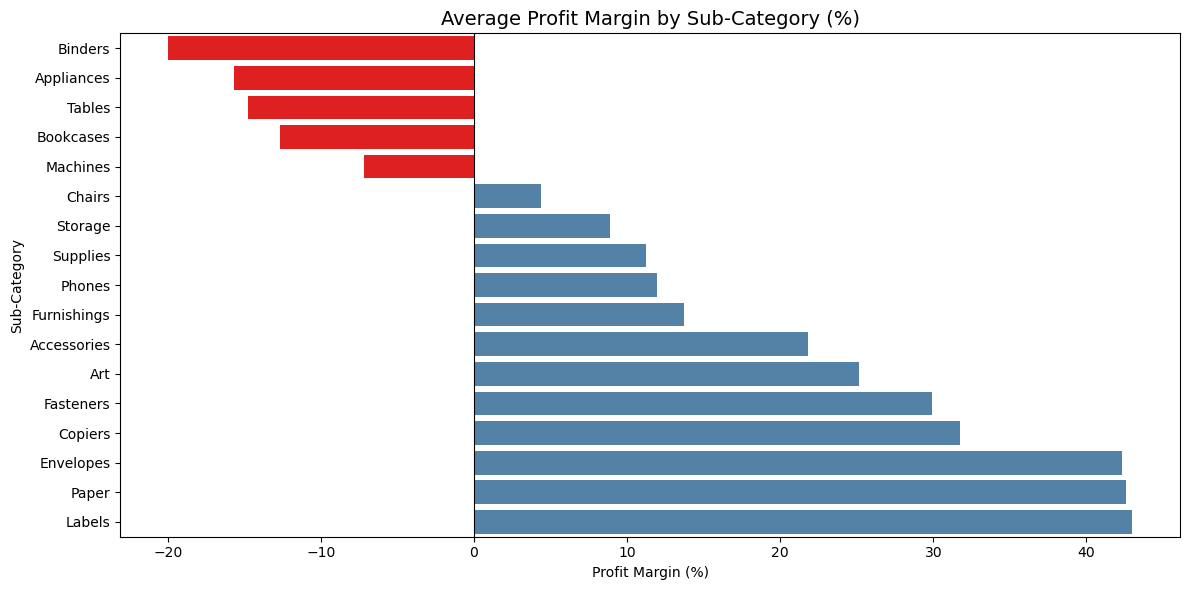

In [6]:
plt.figure(figsize=(12,6))
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
subcat_margin = df.groupby('Sub-Category')['Profit Margin'].mean().sort_values()
colors = ['red' if x < 0 else 'steelblue' for x in subcat_margin.values]
sns.barplot(x=subcat_margin.values, y=subcat_margin.index, palette=colors)
plt.title('Average Profit Margin by Sub-Category (%)', fontsize=14)
plt.xlabel('Profit Margin (%)')
plt.ylabel('Sub-Category')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('margin_by_subcategory.png', dpi=150)
plt.show()

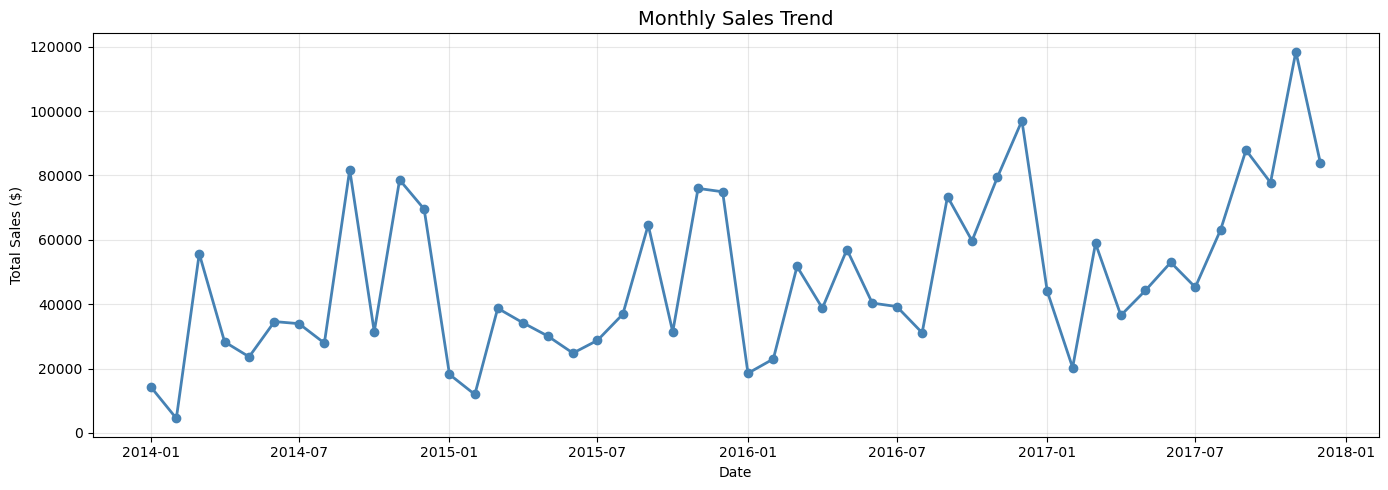

In [7]:
plt.figure(figsize=(14,5))
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year', 'Month']].assign(Day=1))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)
plt.show()

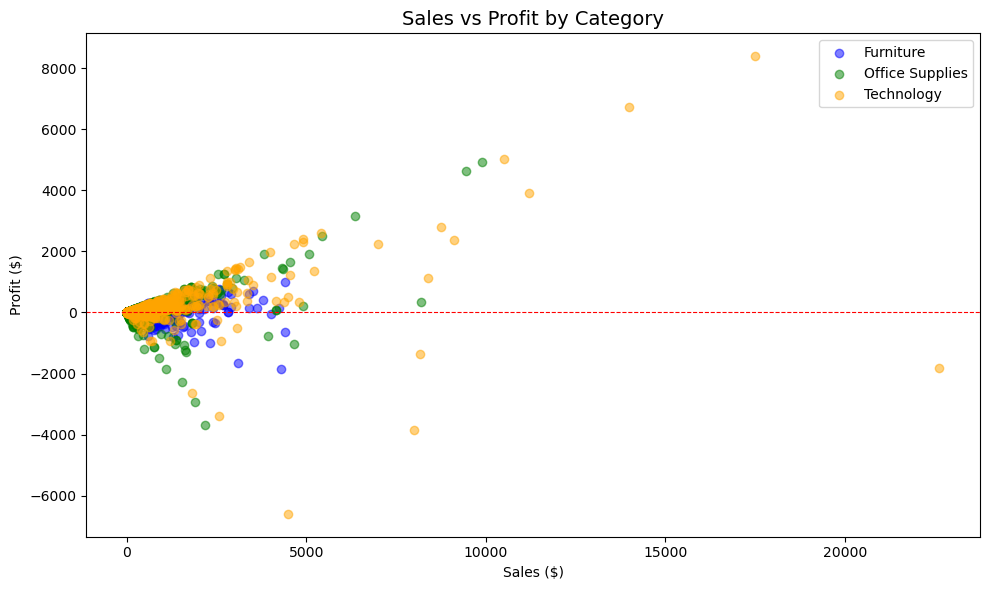

In [8]:
plt.figure(figsize=(10,6))
colors = {'Furniture':'blue', 'Office Supplies':'green', 'Technology':'orange'}
for category, group in df.groupby('Category'):
    plt.scatter(group['Sales'], group['Profit'], 
                label=category, alpha=0.5, color=colors[category])
plt.title('Sales vs Profit by Category', fontsize=14)
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='red', linewidth=0.8, linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig('sales_vs_profit.png', dpi=150)
plt.show()

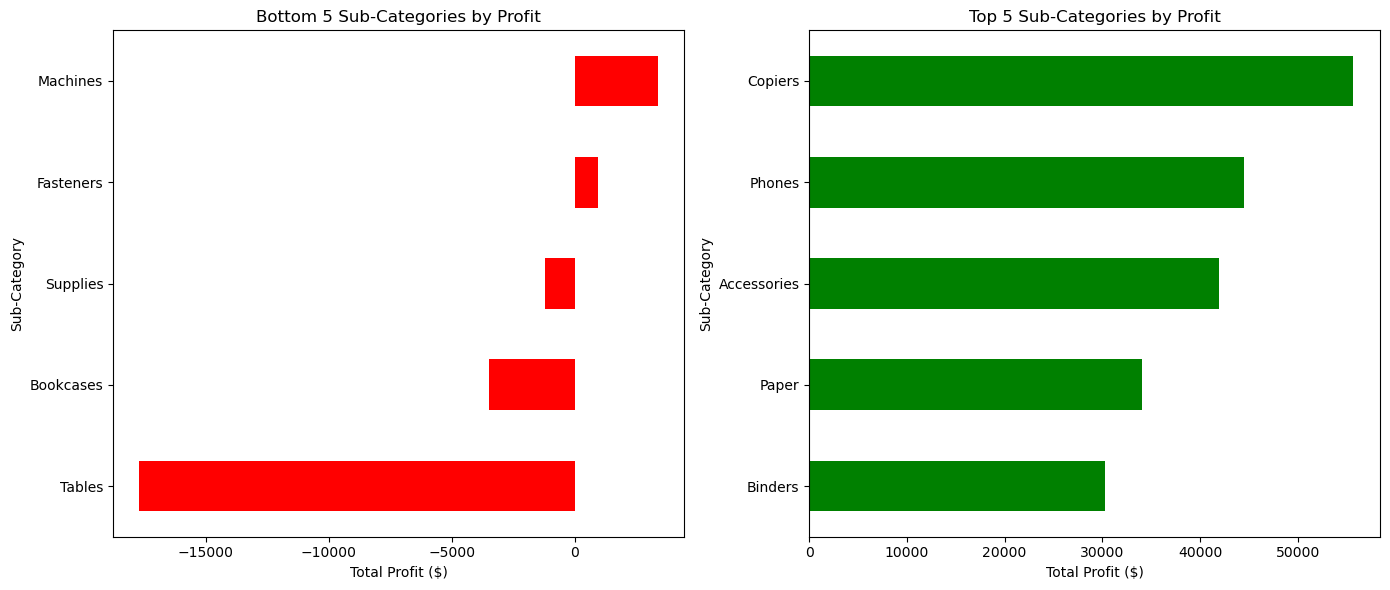

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
subcat_profit.head(5).plot(kind='barh', ax=axes[0], color='red')
axes[0].set_title('Bottom 5 Sub-Categories by Profit', fontsize=12)
axes[0].set_xlabel('Total Profit ($)')

# Top 5 (most profitable)
subcat_profit.tail(5).plot(kind='barh', ax=axes[1], color='green')
axes[1].set_title('Top 5 Sub-Categories by Profit', fontsize=12)
axes[1].set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('top_bottom_subcategories.png', dpi=150)
plt.show()

In [11]:
print("="*50)
print("KEY BUSINESS INSIGHTS")
print("="*50)
print(f"Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Overall Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")
print(f"\nBest Region by Sales: {region_sales.index[0]}")
print(f"Best Category by Sales: {cat_sales.index[0]}")
print(f"Best Category by Profit: {cat_profit.index[0]}")
print(f"\nLoss-making Sub-Categories:")
loss = df.groupby('Sub-Category')['Profit'].sum()
print(loss[loss < 0].sort_values())

KEY BUSINESS INSIGHTS
Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%

Best Region by Sales: West
Best Category by Sales: Technology
Best Category by Profit: Technology

Loss-making Sub-Categories:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64
